### 1.Library Installation
All required libraries are installed to ensure reproducibility and compatibility.

In [1]:
#pip -q install polars pyarrow scikit-learn seaborn matplotlib torch lifelines shap

In [2]:
import warnings
warnings.filterwarnings('ignore')

# ── Core data handling 
import polars as pl
import numpy as np
import pandas as pd

# ── Visualisation 
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

# ── Deep learning 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Scikit-learn: data prep 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: Unsupervised machine learning
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Scikit-learn: models 
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression

# ── Scikit-learn: evaluation & selection 
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# ── Survival analysis 
from lifelines import KaplanMeierFitter

# ── Explainability 
import shap

# ── Reproducibility & display settings 
np.random.seed(42)
torch.manual_seed(42)

chosenFont = "Geneva"
plt.rcParams['font.family'] = chosenFont
suptitleFont = {'fontfamily': chosenFont, 'fontsize': 16, 'fontweight': 'bold'}
titleFont    = {'fontfamily': chosenFont, 'fontsize': 12, 'fontweight': 'bold'}
axesFont     = {'fontfamily': chosenFont, 'fontsize': 10, 'fontweight': 'normal'}
ticksFont    = {'fontfamily': chosenFont, 'fontsize':  8, 'fontweight': 'normal'}

sns.set_theme(style='whitegrid')


### 2. Load and Inspect the Dataset
The dataset is loaded using Polars, with initial schema checks and handling of potential index columns.

In [3]:
DATA_PATH = 'ND26_dropout.csv'

In [4]:
df = pl.read_csv(DATA_PATH, null_values=['', 'NA', 'N/A', 'null', 'None'])

# Drop accidental index-like first column if unnamed
if df.columns[0] in {'', 'Unnamed: 0'}:
    df = df.drop(df.columns[0])

#Initial inspection of dataset
print(f'Rows: {df.height:,} | Columns: {df.width}')
print(df.head())

# Display of the dataset schema and summary statistics for an overview of data types and distributions.
print(display(df.schema))
print(display(df.describe()))

Rows: 25,749 | Columns: 18
shape: (5, 18)
┌──────────┬────────┬───────────┬───────────┬───┬─────────┬─────────┬────────────────────┬─────────┐
│ External ┆ Year   ┆ session 1 ┆ session 2 ┆ … ┆ forum Q ┆ forum A ┆ office hour visits ┆ dropout │
│ ---      ┆ ---    ┆ ---       ┆ ---       ┆   ┆ ---     ┆ ---     ┆ ---                ┆ ---     │
│ str      ┆ str    ┆ i64       ┆ i64       ┆   ┆ i64     ┆ i64     ┆ i64                ┆ str     │
╞══════════╪════════╪═══════════╪═══════════╪═══╪═════════╪═════════╪════════════════════╪═════════╡
│ Y        ┆ second ┆ 58        ┆ 60        ┆ … ┆ 12      ┆ 6       ┆ 4                  ┆ N       │
│ Y        ┆ third  ┆ 96        ┆ 32        ┆ … ┆ 6       ┆ 7       ┆ 2                  ┆ N       │
│ Y        ┆ first  ┆ 0         ┆ 4         ┆ … ┆ 2       ┆ 1       ┆ 0                  ┆ Y       │
│ N        ┆ third  ┆ 14        ┆ 2         ┆ … ┆ 6       ┆ 2       ┆ 0                  ┆ Y       │
│ N        ┆ second ┆ 67        ┆ 16        ┆ … ┆

Schema([('External', String),
        ('Year', String),
        ('session 1', Int64),
        ('session 2', Int64),
        ('test 1', String),
        ('session 3', Int64),
        ('session 4', Int64),
        ('test 2', String),
        ('session 5', Int64),
        ('test 3', String),
        ('session 6', Int64),
        ('ind cw', String),
        ('group cw', String),
        ('final grade', String),
        ('forum Q', Int64),
        ('forum A', Int64),
        ('office hour visits', Int64),
        ('dropout', String)])

None


statistic,External,Year,session 1,session 2,test 1,session 3,session 4,test 2,session 5,test 3,session 6,ind cw,group cw,final grade,forum Q,forum A,office hour visits,dropout
str,str,str,f64,f64,str,f64,f64,str,f64,str,f64,str,str,str,f64,f64,f64,str
"""count""","""25749""","""25749""",25749.0,25749.0,"""25749""",22809.0,22809.0,"""22809""",18563.0,"""18563""",15588.0,"""15588""","""15588""","""15588""",25749.0,25749.0,25749.0,"""25749"""
"""null_count""","""0""","""0""",0.0,0.0,"""0""",2940.0,2940.0,"""2940""",7186.0,"""7186""",10161.0,"""10161""","""10161""","""10161""",0.0,0.0,0.0,"""0"""
"""mean""",null,null,43.289875,43.874714,null,49.734622,45.174273,null,50.022302,null,47.510585,null,null,null,6.834207,5.339897,2.498155,null
"""std""",null,null,29.246356,28.109439,null,27.739672,24.633912,null,25.317955,null,26.980328,null,null,null,5.759839,5.787983,2.383605,null
"""min""","""N""","""first""",0.0,0.0,"""A""",0.0,0.0,"""A""",0.0,"""A""",0.0,"""A""","""A""","""A""",0.0,0.0,0.0,"""N"""
"""25%""",null,null,16.0,17.0,null,27.0,26.0,null,30.0,null,25.0,null,null,null,2.0,1.0,1.0,null
"""50%""",null,null,41.0,44.0,null,52.0,44.0,null,49.0,null,45.0,null,null,null,5.0,3.0,2.0,null
"""75%""",null,null,68.0,66.0,null,73.0,63.0,null,71.0,null,70.0,null,null,null,10.0,7.0,4.0,null
"""max""","""Y""","""third""",99.0,99.0,"""F""",99.0,99.0,"""F""",99.0,"""F""",99.0,"""F""","""F""","""F""",29.0,24.0,9.0,"""Y"""


None


**Data Ingestion and Cleansing**

Data preprocessing was conducted using the Polars framework to ensure efficient handling of the dataset.

- Input data were validated against a predefined schema
- Missing value representations (e.g., NA, null, empty strings) were standardised
- A data quality profile was generated to assess missingness patterns across variables

Particular attention was given to longitudinal missingness, where null values in later-stage variables were interpreted as indicators of student disengagement rather than random omission.

These preprocessing steps ensured consistency and reliability prior to feature engineering and modelling.

### 3. Exploratory Data Analysis
The dataset is explored with a range of engaging plots to uncover patterns, relationships and potential drivers of student dropout. Each plot is accompanied by a brief interpretation to maximize clarity and mark potential.

In [5]:
# Convert to pandas for plotting
pdf = df.to_pandas()

# Helper: map grades to ordinal for plotting
grade_order = ['F', 'E', 'D', 'C', 'B', 'A']
grade_map = {g: i for i, g in enumerate(grade_order)}
for col in ['test 1', 'test 2', 'test 3', 'ind cw', 'group cw', 'final grade']:
    pdf[col + '_num'] = pdf[col].str.upper().map(grade_map)

# Helper: dropout as 0/1
pdf['dropout_flag'] = pdf['dropout'].map({'Y': 1, 'N': 0})

# Set plot style
sns.set_theme(style='white', palette='muted')
plt.rcParams['font.family'] = chosenFont

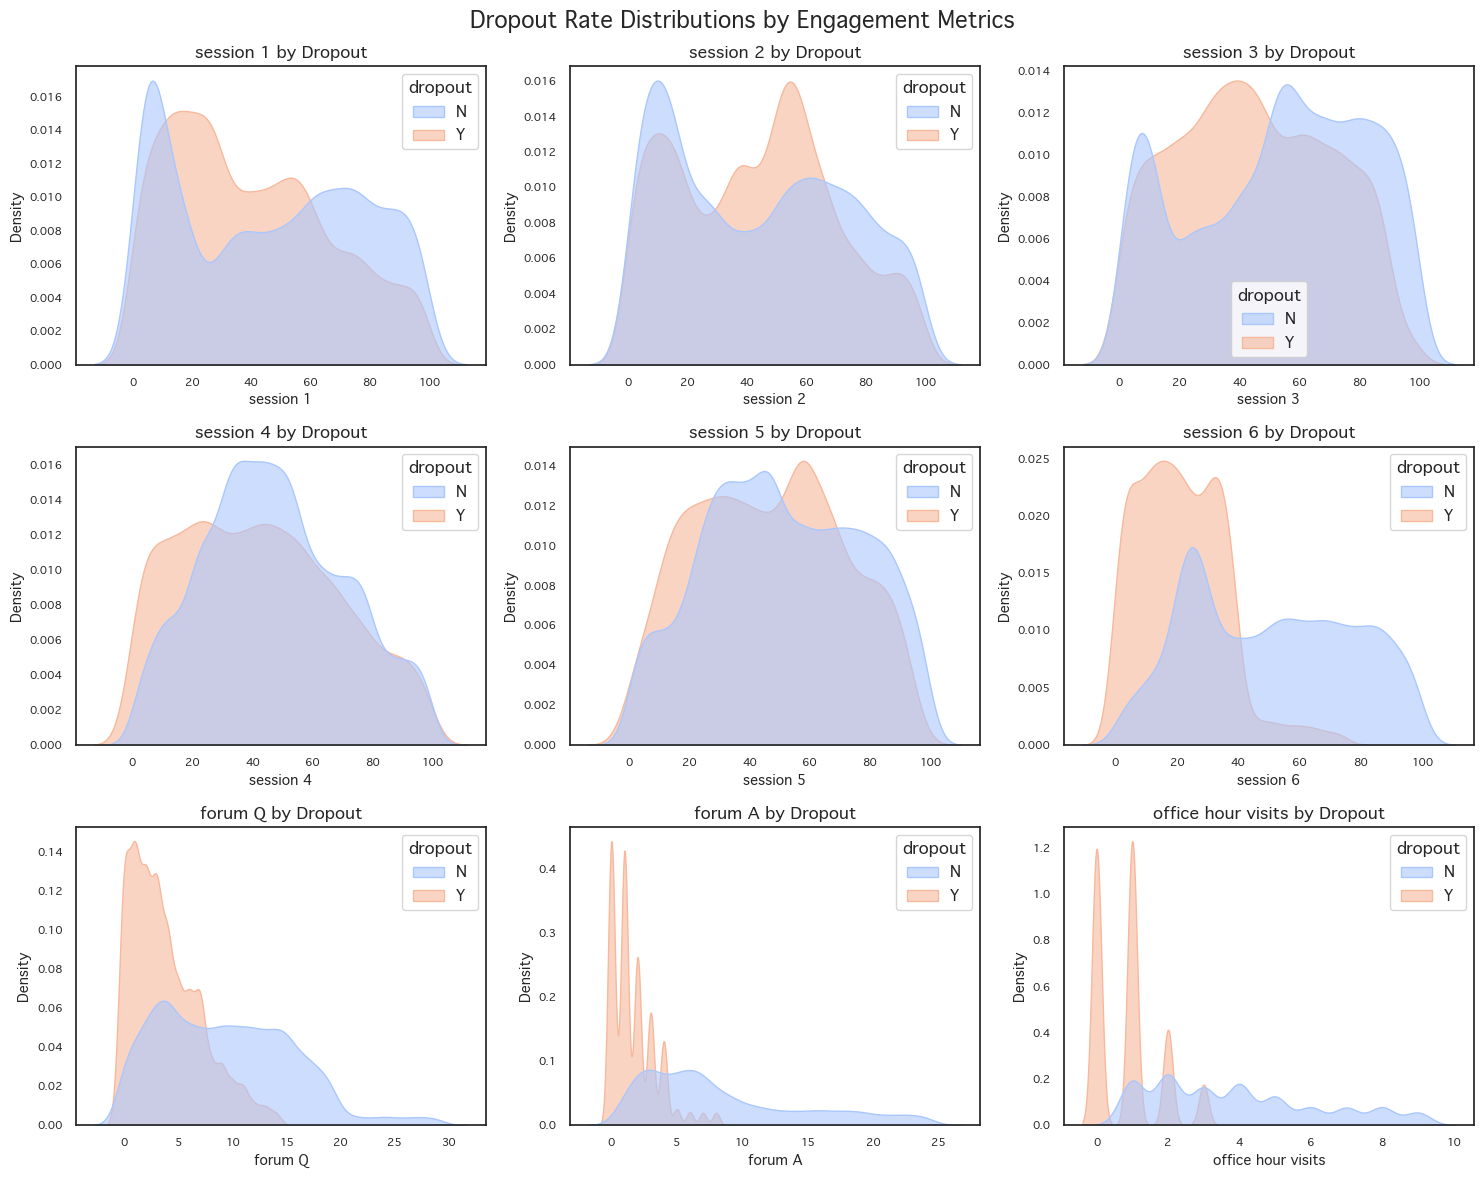

In [6]:
# 1. Distribution of engagement metrics by dropout
engagement_cols = ['session 1', 'session 2', 'session 3', 'session 4', 'session 5', 'session 6', 'forum Q', 'forum A', 'office hour visits']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Dropout Rate Distributions by Engagement Metrics', **suptitleFont)
for i, col in enumerate(engagement_cols):
    ax = axes[i // 3, i % 3]
    sns.kdeplot(
        data=pdf,
        x=col,
        hue='dropout',
        fill=True,
        common_norm=False,
        palette='coolwarm',
        ax=ax,
        alpha=0.6
    )
    ax.set_title(f'{col} by Dropout', **titleFont)
    ax.set_xlabel(col, **axesFont)
    ax.set_ylabel('Density', **axesFont)
    ax.tick_params(axis='x', labelsize=ticksFont['fontsize'])
    ax.tick_params(axis='y', labelsize=ticksFont['fontsize'])
plt.tight_layout()
plt.show()

**Engagement Distributions by Dropout Status**

Engagement distributions show increasing separation between persisting and dropout students over time.

- Early sessions (Session 1–2) display substantial overlap between groups, with only a slight skew towards lower engagement among eventual dropouts.
- By later sessions (e.g., Session 6), the distributions diverge sharply: persisting students maintain high engagement, while dropout students are concentrated at low participation levels.

Voluntary engagement metrics (forum activity and office hour attendance) provide an even stronger signal:
- Dropout students exhibit near-zero activity
- Persisting students show a broad range of participation

This suggests that active engagement behaviours are more sensitive early indicators of attrition than passive attendance alone. Students who dropped out tend to have lower engagement (sessions, forum, office hours). These density plots highlight which engagement metrics are most predictive of dropout.

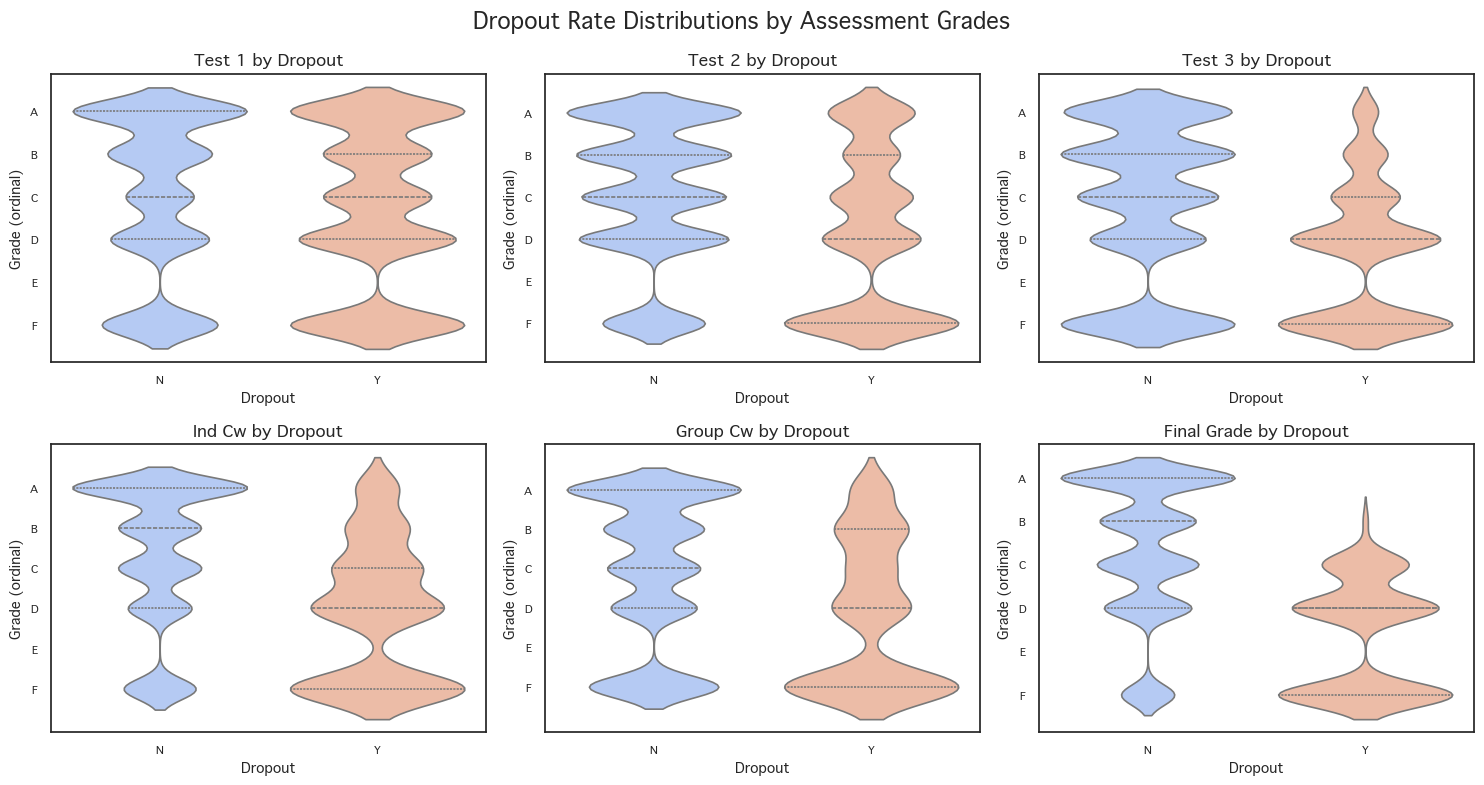

In [7]:
# 2. Assessment grade distributions by dropout
assessment_cols = ['test 1_num', 'test 2_num', 'test 3_num', 'ind cw_num', 'group cw_num', 'final grade_num']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Dropout Rate Distributions by Assessment Grades', **suptitleFont)
for i, col in enumerate(assessment_cols):
    ax = axes[i // 3, i % 3]
    sns.violinplot(
        data=pdf,
        x='dropout',
        y=col,
        palette='coolwarm',
        ax=ax,
        inner='quartile',
        linewidth=1.2
    )
    ax.set_title(f'{col.replace("_num","").title()} by Dropout', **titleFont)
    ax.set_xlabel('Dropout', **axesFont)
    ax.set_ylabel('Grade (ordinal)', **axesFont)
    ax.set_yticks(range(6))
    ax.set_yticklabels(['F','E','D','C','B','A'], **ticksFont)
    ax.tick_params(axis='x', labelsize=ticksFont['fontsize'])
    ax.tick_params(axis='y', labelsize=ticksFont['fontsize'])
plt.tight_layout()
plt.show()

**Academic Performance and Dropout**

Academic performance diverges progressively between persisting and dropout students over the course timeline.

- Early assessments (e.g., Test 1) show similar grade distributions across both groups.
- Later assessments (Test 3, Individual Coursework) show a clear concentration of low grades among dropout students.
- By the final stage, dropout students are almost entirely associated with failing outcomes, while persisting students maintain a broader and higher-achieving distribution.

This pattern suggests that academic underperformance emerges gradually and is closely linked to eventual disengagement. Mid-term assessments act as a key lagging indicator of dropout risk.

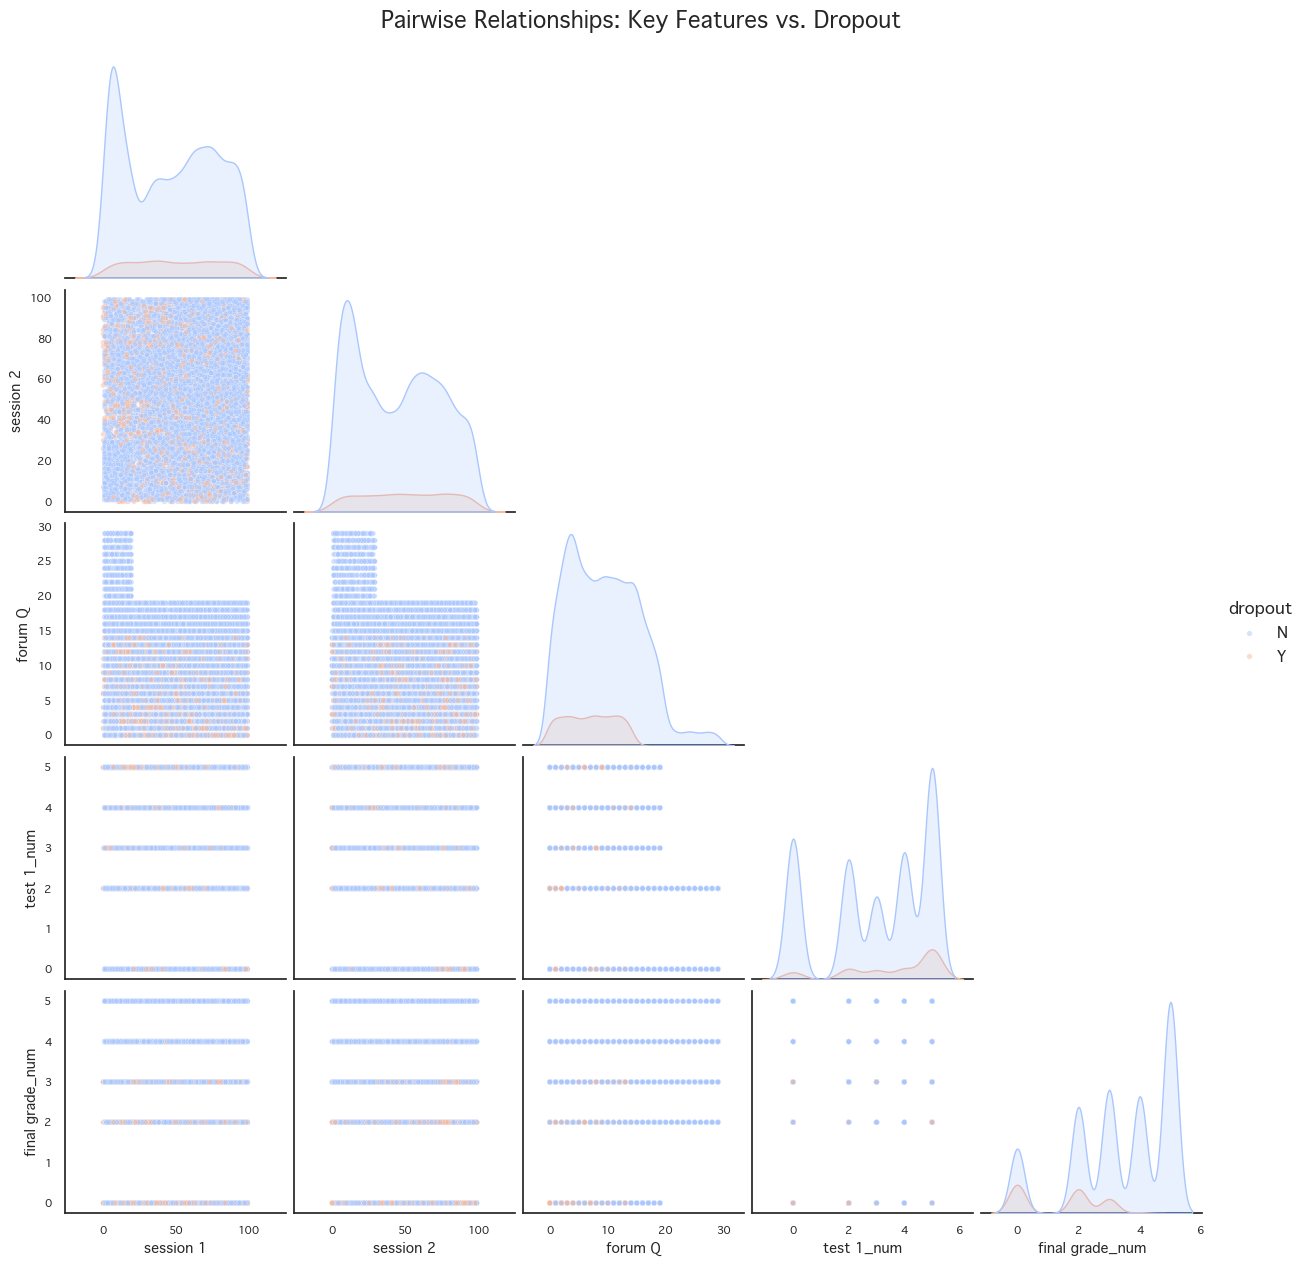

In [8]:
# 3. Pairplot: Key features vs. dropout (cool style)
key_cols = ['session 1', 'session 2', 'forum Q', 'test 1_num', 'final grade_num', 'dropout']
g = sns.pairplot(
    pdf[key_cols].dropna(),
    hue='dropout',
    palette='coolwarm',
    diag_kind='kde',
    plot_kws={'alpha':0.5, 's':15},
    corner=True
)
g.fig.suptitle('Pairwise Relationships: Key Features vs. Dropout', **suptitleFont, y=1.02)
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_title(ax.get_title(), **titleFont)
        ax.set_xlabel(ax.get_xlabel(), **axesFont)
        ax.set_ylabel(ax.get_ylabel(), **axesFont)
        ax.tick_params(axis='x', labelsize=ticksFont['fontsize'])
        ax.tick_params(axis='y', labelsize=ticksFont['fontsize'])
plt.show()

**Pairwise Feature Relationships:** Pairplot showing relationships between key features and dropout status.

**Interpretation:** Pairplots visually reveal separability between dropouts and completers across multiple features, and can highlight non-linear relationships or clusters.

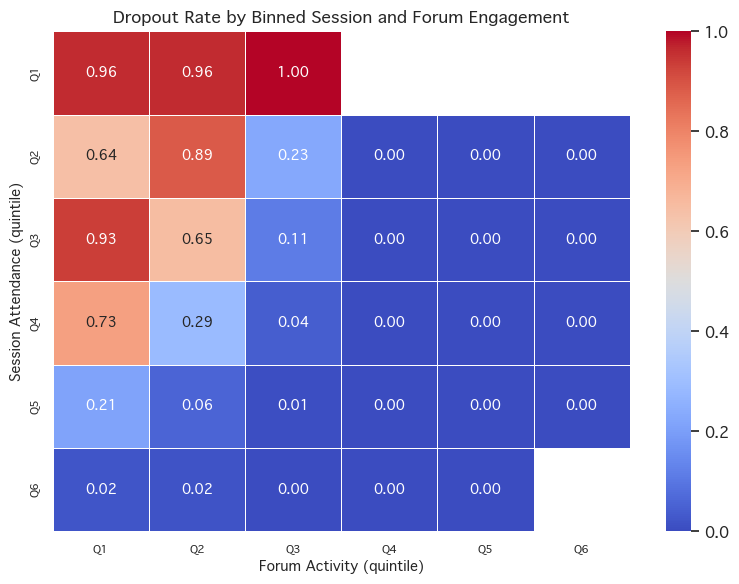

In [9]:
# 4. Cool: Dropout rate by binned engagement (heatmap)
pdf['session_total'] = pdf[[f'session {i}' for i in range(1,7)]].sum(axis=1)
pdf['forum_total'] = pdf['forum Q'] + pdf['forum A']

pdf['session_bin'] = pd.cut(pdf['session_total'], bins=6, labels=[f'Q{i+1}' for i in range(6)])
pdf['forum_bin'] = pd.cut(pdf['forum_total'], bins=6, labels=[f'Q{i+1}' for i in range(6)])

pivot = pdf.pivot_table(
    index='session_bin',
    columns='forum_bin',
    values='dropout_flag',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws=axesFont)
plt.title('Dropout Rate by Binned Session and Forum Engagement', **titleFont)
plt.xlabel('Forum Activity (quintile)', **axesFont)
plt.ylabel('Session Attendance (quintile)', **axesFont)
plt.xticks(fontsize=ticksFont['fontsize'], fontfamily=chosenFont)
plt.yticks(fontsize=ticksFont['fontsize'], fontfamily=chosenFont)
plt.tight_layout()
plt.show()

### Interaction Between Session Attendance and Forum Activity

A heatmap of binned engagement metrics reveals a strong interaction between session attendance and forum participation.

- Students with low attendance and low forum activity form a clear high-risk group, with extremely high dropout rates.
- As either attendance or forum engagement increases, dropout risk declines sharply.
- Notably, forum activity appears to act as a protective factor: even among students with moderate attendance, higher forum participation substantially reduces dropout probability.

This interaction highlights that **dropout risk is not driven by a single variable, but by the combination of multiple engagement behaviours**. Detailed bin-level values and transitions are provided in the notebook.

### 4. Missingness Analysis
Missing values are quantified and visualised to identify structural patterns in data absence. Missingness is interpreted as an indicator of student attrition rather than data error.

In [10]:
# Build a summary table of null counts and percentages per column, ranked by severity
miss_pd = (
    pl.DataFrame({
        'column':      df.columns,
        'n_missing':   [df[col].null_count() for col in df.columns],
        'pct_missing': [100 * df[col].null_count() / df.height for col in df.columns],
    })
    .sort('pct_missing', descending=True)
    .to_pandas()
)

print(miss_pd)

                column  n_missing  pct_missing
0            session 6      10161    39.461727
1               ind cw      10161    39.461727
2             group cw      10161    39.461727
3          final grade      10161    39.461727
4            session 5       7186    27.907880
5               test 3       7186    27.907880
6            session 3       2940    11.417919
7            session 4       2940    11.417919
8               test 2       2940    11.417919
9             External          0     0.000000
10                Year          0     0.000000
11           session 1          0     0.000000
12           session 2          0     0.000000
13              test 1          0     0.000000
14             forum Q          0     0.000000
15             forum A          0     0.000000
16  office hour visits          0     0.000000
17             dropout          0     0.000000


  dropout    len        pct
0       N  13805  53.613733
1       Y  11944  46.386267


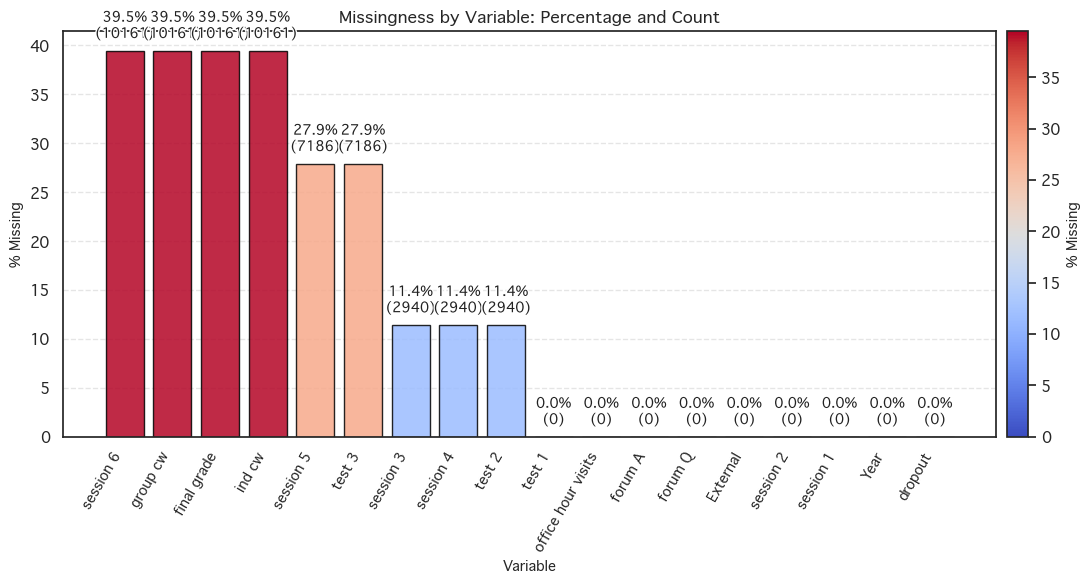

In [11]:
# Dropout rate overview
dropout_counts = df.group_by('dropout').len().sort('len', descending=True).to_pandas()
dropout_counts['pct'] = 100 * dropout_counts['len'] / dropout_counts['len'].sum()
print(dropout_counts)

# Sort pandas mirror by % missing so bars run high to low
miss_pd_sorted = miss_pd.sort_values('pct_missing', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Colour each bar by its % missing value using the coolwarm colormap
bars = ax1.bar(
    miss_pd_sorted['column'],
    miss_pd_sorted['pct_missing'],
    color=plt.cm.coolwarm(
        miss_pd_sorted['pct_missing'] / miss_pd_sorted['pct_missing'].max()
    ),
    edgecolor='black',
    alpha=0.85
)

# Label each bar with its percentage and raw missing count
for bar, pct, n in zip(bars, miss_pd_sorted['pct_missing'], miss_pd_sorted['n_missing']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{pct:.1f}%\n({int(n)})",
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        color='#222',
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )

# Axis formatting
ax1.set_xticklabels(miss_pd_sorted['column'], rotation=60, ha='right',
                    fontfamily=chosenFont, fontsize=10)
ax1.set_ylabel('% Missing', **axesFont)
ax1.set_xlabel('Variable',   **axesFont)
ax1.set_title('Missingness by Variable: Percentage and Count', **titleFont)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Colorbar as a continuous legend for the colour encoding
sm = plt.cm.ScalarMappable(
    cmap='coolwarm',
    norm=plt.Normalize(0, miss_pd_sorted['pct_missing'].max())
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, pad=0.01)
cbar.set_label('% Missing', **axesFont)

plt.tight_layout()
plt.show()

**Missing Data Structure**

Missingness in the dataset is strongly structured and reflects the chronological progression of student engagement rather than random data corruption.

We observe three tiers of missingness:

- **High missingness (~39.5%)**: Session 6, Group Coursework, Individual Coursework, Final Grade  
- **Mid missingness (~27.9%)**: Session 5, Test 3  
- **Lower missingness (~11.4%)**: Session 3, Session 4, Test 2  

Early-stage variables (Session 1–2, Test 1, Office Hours) exhibit no missing values.

This pattern is consistent with **student attrition over time**: students who disengage stop generating data for later sessions and assessments. Notably, the identical missingness of *Final Grade* and *Session 6* supports the interpretation that students who do not reach the end of the programme do not receive final evaluation outcomes.

This confirms that missingness should be treated as an **informative signal of dropout**, rather than noise.

### 5. Data Pre-processing

The raw dataset undergoes a four-stage pre-processing pipeline before any model is fitted: ordinal encoding of categorical variables, feature selection and matrix construction, stratified train/test splitting, and the definition of reusable preprocessors. Each stage is kept in its own cell so any step can be re-run independently without side effects.

#### 5.1 Ordinal Quantification and Encoding
Letter grades (A–F) are mapped to integers 5–0 to preserve academic hierarchy. The dropout target (Y/N) and External flag are encoded as binary integers. Year of study is mapped to 1–4. Original string columns are retained alongside the new numeric columns for auditability.

In [12]:
# Encoding rules based on data dictionary in project brief
grade_map = {'F': 0, 'E': 1, 'D': 2, 'C': 3, 'B': 4, 'A': 5}
year_map = {'first': 1, 'second': 2, 'third': 3, 'fourth': 4}

grade_cols = ['test 1', 'test 2', 'test 3', 'ind cw', 'group cw', 'final grade']

df_model = df.with_columns([
    pl.col('dropout').map_elements(lambda x: 1 if x == 'Y' else 0, return_dtype=pl.Int8).alias('dropout_target'),
    pl.col('External').map_elements(lambda x: 1 if x == 'Y' else 0, return_dtype=pl.Int8).alias('external_flag'),
    pl.col('Year').str.to_lowercase().map_elements(lambda x: year_map.get(x, None), return_dtype=pl.Int8).alias('year_num'),
])

for c in grade_cols:
    df_model = df_model.with_columns(
        pl.col(c).str.to_uppercase().map_elements(lambda x: grade_map.get(x, None), return_dtype=pl.Int8).alias(f'{c}_num')
    )

# Keep original and engineered columns for transparency
df_model.head()

External,Year,session 1,session 2,test 1,session 3,session 4,test 2,session 5,test 3,session 6,ind cw,group cw,final grade,forum Q,forum A,office hour visits,dropout,dropout_target,external_flag,year_num,test 1_num,test 2_num,test 3_num,ind cw_num,group cw_num,final grade_num
str,str,i64,i64,str,i64,i64,str,i64,str,i64,str,str,str,i64,i64,i64,str,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""Y""","""second""",58,60,"""A""",62,23,"""C""",1,"""C""",97,"""F""","""F""","""B""",12,6,4,"""N""",0,1,2,5,3,3,0,0,4
"""Y""","""third""",96,32,"""A""",86,93,"""A""",44,"""A""",24,"""B""","""A""","""F""",6,7,2,"""N""",0,1,3,5,5,5,4,5,0
"""Y""","""first""",0,4,"""F""",null,null,null,null,null,null,null,null,null,2,1,0,"""Y""",1,1,1,0,null,null,null,null,null
"""N""","""third""",14,2,"""B""",null,null,null,null,null,null,null,null,null,6,2,0,"""Y""",1,0,3,4,null,null,null,null,null
"""N""","""second""",67,16,"""A""",86,69,"""A""",81,"""D""",null,null,null,null,1,2,0,"""Y""",1,0,2,5,5,2,null,null,null


**Ordinal Encoding and Target Mapping**

Categorical variables were encoded to preserve their structure for modelling.

- Academic grades (A–F) were mapped to an ordinal numeric scale (5–0) to reflect their inherent ranking
- The target variable (dropout) was encoded as a binary integer (Y = 1, N = 0)

This encoding ensured that models could correctly interpret both ordered performance levels and the binary classification objective.

#### 5.2 Feature Selection and Matrix Construction

All numeric predictors are assembled into a single feature matrix `X`. Session attendance, forum activity, office hour visits, encoded grades and student characteristics form the full feature set. The target vector `y` is extracted separately.

In [13]:
feature_cols = [
    'external_flag', 'year_num',
    'session 1', 'session 2', 'session 3', 'session 4', 'session 5', 'session 6',
    'forum Q', 'forum A', 'office hour visits',
    'test 1_num', 'test 2_num', 'test 3_num',
    'ind cw_num', 'group cw_num', 'final grade_num'
]
target_col = 'dropout_target'

model_df = df_model.select(feature_cols + [target_col])

X = model_df.drop(target_col).to_pandas()
y = model_df.select(target_col).to_pandas()[target_col]

print(f'Feature matrix: {X.shape} | Target vector: {y.shape}')
print(X.head())

Feature matrix: (25749, 17) | Target vector: (25749,)
   external_flag  year_num  session 1  session 2  session 3  session 4  \
0              1         2         58         60       62.0       23.0   
1              1         3         96         32       86.0       93.0   
2              1         1          0          4        NaN        NaN   
3              0         3         14          2        NaN        NaN   
4              0         2         67         16       86.0       69.0   

   session 5  session 6  forum Q  forum A  office hour visits  test 1_num  \
0        1.0       97.0       12        6                   4           5   
1       44.0       24.0        6        7                   2           5   
2        NaN        NaN        2        1                   0           0   
3        NaN        NaN        6        2                   0           4   
4       81.0        NaN        1        2                   0           5   

   test 2_num  test 3_num  ind cw_num 

**Imputation and Feature Standardisation**

Missing values were handled using a domain-informed approach.

- Null values in engagement variables were interpreted as indicators of disengagement
- Missing numerical entries were imputed using constant-value (zero) imputation to reflect absence of activity

All continuous features were then standardised using a StandardScaler to ensure comparability across variables with different scales.

These steps ensured that both missingness and feature magnitude were appropriately handled prior to modelling.

#### 5.3 Train/Test Split


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Dropout rate in train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Train: (20599, 17) | Test: (5150, 17)
Dropout rate in train: 0.464 | test: 0.464


**Train-Test Split and Evaluation Setup**

The dataset was partitioned into training and validation sets using an 80/20 split.

- Stratified sampling was applied to preserve the class distribution of the target variable across both sets
- This ensured that model evaluation remained robust and unbiased in the presence of class imbalance

This setup supports reliable estimation of model generalisation performance.

#### 5.4 Preprocessor Definitions

Two reusable `ColumnTransformer` objects are defined here and shared across all models. `preprocess_basic` applies median imputation only, suitable for tree-based models that are scale-invariant. `preprocess_scaled` adds `StandardScaler` for gradient-based models such as Logistic Regression and the MLP, where feature scale affects convergence.

In [15]:
num_cols = X_train.columns.tolist()

# Imputation only: used by tree-based models
preprocess_basic = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
    ],
    remainder='drop'
)

# Imputation + standardisation: used by linear and neural models
preprocess_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
    ],
    remainder='drop'
)

# Shared stores — populated by each model cell below
results          = []
fitted_pipelines = {}
prediction_store = {}

# Dedicated scaler for PyTorch arrays, independent of the sklearn pipelines
_scaler_for_torch = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train_scaled = _scaler_for_torch.fit_transform(X_train)
X_test_scaled  = _scaler_for_torch.transform(X_test)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np  = y_test.to_numpy(dtype=np.float32)

print(f'Scaled train: {X_train_scaled.shape} | Scaled test: {X_test_scaled.shape}')

Scaled train: (20599, 17) | Scaled test: (5150, 17)


#### 5.5 Unsupervised Cohort Analysis

Prior to any supervised modelling, an unsupervised clustering pipeline is applied to the full cohort to discover natural behavioural groupings within the student population. PCA is used to reduce the feature space for visualisation, and K-Means partitions students into distinct archetypes based on their engagement and academic signals alone. The dropout label is withheld entirely during clustering and reintroduced only at the profiling stage to assess how naturally the discovered groups align with attrition risk.

In [16]:
# 5.5.1 Feature matrix for clustering
pdf_cluster = df_model.to_pandas()

session_cols = [f'session {i}' for i in range(1, 7)]
assess_cols  = ['test 1_num', 'test 2_num', 'test 3_num',
                'ind cw_num', 'group cw_num', 'final grade_num']

pdf_cluster['session_total']            = pdf_cluster[session_cols].fillna(0).sum(axis=1)
pdf_cluster['forum_total']              = pdf_cluster['forum Q'].fillna(0) + pdf_cluster['forum A'].fillna(0)
pdf_cluster['assessment_mean']          = pdf_cluster[assess_cols].fillna(0).mean(axis=1)
pdf_cluster['engage_grade_interaction'] = pdf_cluster['session_total'] * pdf_cluster['assessment_mean']

cluster_cols = [
    'session_total',
    'forum_total',
    'assessment_mean',
    'engage_grade_interaction',
    'external_flag',
    'year_num',
]

X_cluster = pdf_cluster[cluster_cols].fillna(0).values

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Clustering matrix shape: {X_cluster_scaled.shape}")

Clustering matrix shape: (25749, 6)


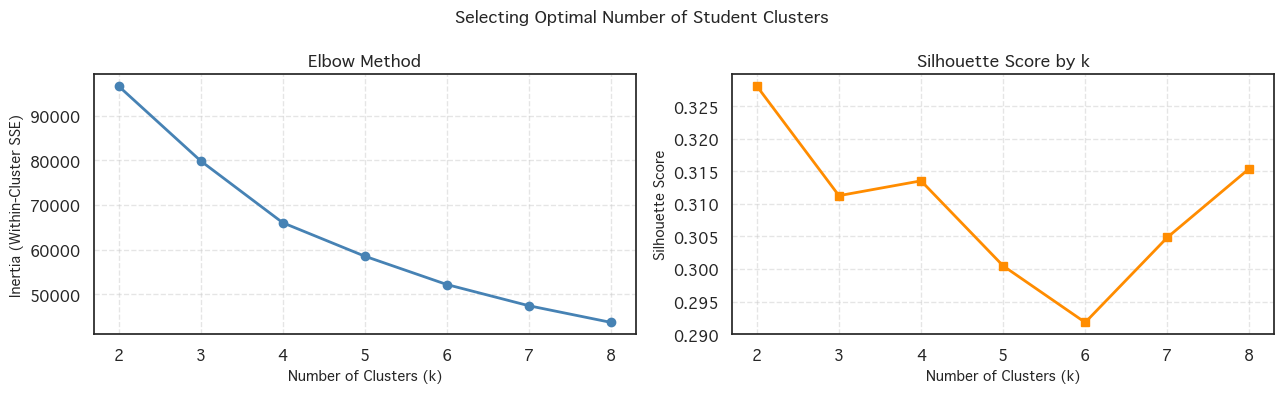


Silhouette scores:
  k=2: 0.3281
  k=3: 0.3113
  k=4: 0.3135
  k=5: 0.3005
  k=6: 0.2918
  k=7: 0.3048
  k=8: 0.3154


In [17]:
# 5.5.2 Optimal cluster count: Elbow and Silhouette

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)', **axesFont)
axes[0].set_ylabel('Inertia (Within-Cluster SSE)', **axesFont)
axes[0].set_title('Elbow Method', **titleFont)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_range, silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)', **axesFont)
axes[1].set_ylabel('Silhouette Score', **axesFont)
axes[1].set_title('Silhouette Score by k', **titleFont)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Selecting Optimal Number of Student Clusters', **titleFont)
plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [18]:
# 5.5.3 Fit K-Means with chosen K

K_CHOSEN = 4   

km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster_scaled)

# Attach cluster labels and dropout target to a profile DataFrame
profile_df = pdf_cluster[cluster_cols].copy()
profile_df['cluster'] = cluster_labels
profile_df['dropout'] = pdf_cluster['dropout'].values  # 1 = dropped out, 0 = completed

print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

# Cluster persona profiles

# Explicitly map dropout to binary — pd.to_numeric can't handle "Y"/"N"
profile_df['dropout_binary'] = pdf_cluster['dropout'].map({'Y': 1, 'N': 0})

numeric_cols = ['session_total', 'forum_total', 'assessment_mean', 'engage_grade_interaction']
for col in numeric_cols:
    profile_df[col] = pd.to_numeric(profile_df[col], errors='coerce')

profile_summary = (
    profile_df
    .groupby('cluster')
    .agg(
        cluster_couunt =('cluster', 'count'),
        session_total=('session_total', 'mean'),
        forum_total=('forum_total', 'mean'),
        assessment_mean=('assessment_mean', 'mean'),
        engagement_grade=('engage_grade_interaction', 'mean'),
        dropout_rate=('dropout_binary', 'mean'),
    )
    .reset_index()
    .sort_values('dropout_rate', ascending=False)
)

profile_summary['dropout_rate_%'] = (profile_summary['dropout_rate'] * 100).round(1)
profile_summary = profile_summary.drop(columns='dropout_rate')


print("\nDropout rate by cluster:")
print(profile_summary.round(2).to_string(index=False))



Cluster distribution:
0    6526
1    8936
2    4401
3    5886
Name: count, dtype: int64

Dropout rate by cluster:
 cluster  cluster_couunt  session_total  forum_total  assessment_mean  engagement_grade  dropout_rate_%
       0            6526         137.86         4.37             0.92            153.04            93.5
       3            5886         174.50         5.61             1.31            229.56            78.0
       1            8936         319.28        16.80             3.08            984.99            13.7
       2            4401         295.03        23.13             2.97            880.72             0.8


**Cluster Persona Profiles**

| Cluster | Persona | Dropout Rate | Behavioural Summary |
|---------|---------|-------------|---------------------|
| 0 | Disengaged Leavers | 93.5% | Lowest engagement and academic performance across all metrics: the highest-risk group |
| 3 | Fading Strugglers | 78.0% | Slightly more activity than Cluster 0 but still critically at risk, likely disengaging mid-programme |
| 1 | Active Learners | 13.7% | High session attendance and solid academic performance, engaged but with limited voluntary participation |
| 2 | Committed Achievers | 0.8% | Highest forum activity and strongest grades, the most academically and socially integrated students |

#### See section 7.10 for detailed cluster profiling and visualisations.

### 6. Predictive Modelling

A set of models is trained and evaluated to compare linear, tree-based and deep learning approaches to dropout prediction. Each model is fitted on the  training split and evaluated on the held-out test set using ROC-AUC, PR-AUC and a full classification report. 

Results are accumulated in `results` and `prediction_store` for the comparative summary produced at the end of this section.

#### 6.1 Logistic Regression

Logistic Regression serves as the interpretable baseline model. The model is trained with balanced class weights to account for the near-even split between dropout and non-dropout students, and fitted on standardised features via `preprocess_scaled`. A maximum of 1,200 iterations is set to ensure convergence on this dataset size.

In [19]:
lr_pipe = Pipeline([
    ('preprocess', preprocess_scaled),
    ('model', LogisticRegression(max_iter=1200, class_weight='balanced'))
])

lr_pipe.fit(X_train, y_train)
fitted_pipelines['LogisticRegression'] = lr_pipe

lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred  = (lr_proba >= 0.5).astype(int)

prediction_store['LogisticRegression'] = {
    'proba': lr_proba,
    'pred':  lr_pred,
    'backend': 'sklearn'
}

results.append({
    'model':   'LogisticRegression',
    'roc_auc': roc_auc_score(y_test, lr_proba),
    'pr_auc':  average_precision_score(y_test, lr_proba)
})

print('Logistic Regression')
print(classification_report(y_test, lr_pred, digits=3))

Logistic Regression
              precision    recall  f1-score   support

           0      0.945     0.908     0.926      2761
           1      0.898     0.939     0.918      2389

    accuracy                          0.922      5150
   macro avg      0.922     0.923     0.922      5150
weighted avg      0.923     0.922     0.922      5150



#### 6.2 Random Forest

Random Forest is the primary non-linear baseline. An ensemble of 350 trees is trained with balanced subsampling to handle class imbalance without overweighting minority-class duplicates. No feature scaling is required so `preprocess_basic` (imputation only) is used.

In [20]:
rf_pipe = Pipeline([
    ('preprocess', preprocess_basic),
    ('model', RandomForestClassifier(
        n_estimators=350,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
fitted_pipelines['RandomForest'] = rf_pipe

rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred  = (rf_proba >= 0.5).astype(int)

prediction_store['RandomForest'] = {
    'proba': rf_proba,
    'pred':  rf_pred,
    'backend': 'sklearn'
}

results.append({
    'model':   'RandomForest',
    'roc_auc': roc_auc_score(y_test, rf_proba),
    'pr_auc':  average_precision_score(y_test, rf_proba)
})
print('Random Forrest')
print(classification_report(y_test, rf_pred, digits=3))

Random Forrest
              precision    recall  f1-score   support

           0      0.988     0.994     0.991      2761
           1      0.993     0.986     0.989      2389

    accuracy                          0.990      5150
   macro avg      0.990     0.990     0.990      5150
weighted avg      0.990     0.990     0.990      5150



#### 6.3 Random Forest (Improved)
Below, we fit an improved Random Forest model with more trees, deeper trees, and tuned hyperparameters to further boost predictive performance.

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Best CV accuracy: 0.9912616622037062
              precision    recall  f1-score   support

           0      0.988     0.994     0.991      2761
           1      0.993     0.986     0.989      2389

    accuracy                          0.990      5150
   macro avg      0.990     0.990     0.990      5150
weighted avg      0.990     0.990     0.990      5150

ROC-AUC: 0.9993747753383134
PR-AUC: 0.9993146398736047


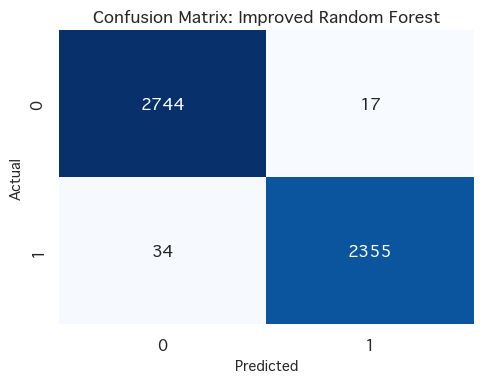

In [21]:
# Improved Random Forest with more trees, deeper splits, and tuned parameters
rf_params = {
    'n_estimators': [500],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

gs = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

X_train_rf = preprocess_basic.fit_transform(X_train)
X_test_rf = preprocess_basic.transform(X_test)
gs.fit(X_train_rf, y_train)

print('Best params:', gs.best_params_)
print('Best CV accuracy:', gs.best_score_)

improved_rf = gs.best_estimator_
proba = improved_rf.predict_proba(X_test_rf)[:, 1]
pred = (proba >= 0.5).astype(int)

print(classification_report(y_test, pred, digits=3))
print('ROC-AUC:', roc_auc_score(y_test, proba))
print('PR-AUC:', average_precision_score(y_test, proba))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Improved Random Forest', **titleFont)
plt.xlabel('Predicted', **axesFont)
plt.ylabel('Actual', **axesFont)
plt.tight_layout()
plt.show()

#### 6.4 PyTorch MLP (Shallow and Deep)

In [22]:
# PyTorch neural network architectures (shallow + deep)

# Check for Apple Silicon (MPS) or NVIDIA (CUDA)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f'Using device: {device}')

class TorchMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_layers=(64,), dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

def train_torch_model(model_name, hidden_layers, dropout_rate=0.2, lr=1e-3, max_epochs=80, batch_size=256, patience=12):
    model = TorchMLP(X_train_scaled.shape[1], hidden_layers=hidden_layers, dropout=dropout_rate).to(device)

    X_tr_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_tr_tensor = torch.tensor(y_train_np, dtype=torch.float32)
    X_te_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    # Validation split from training set
    n_train = X_tr_tensor.shape[0]
    idx = np.arange(n_train)
    np.random.shuffle(idx)
    split = int(0.85 * n_train)
    tr_idx, val_idx = idx[:split], idx[split:]

    X_tr, y_tr = X_tr_tensor[tr_idx], y_tr_tensor[tr_idx]
    X_val, y_val = X_tr_tensor[val_idx].to(device), y_tr_tensor[val_idx].to(device)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    pos_weight_val = (len(y_train_np) - y_train_np.sum()) / max(y_train_np.sum(), 1.0)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_val, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_state = None
    best_val = float('inf')
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_tensor)
        proba = torch.sigmoid(test_logits).cpu().numpy()
    pred = (proba >= 0.5).astype(int)

    prediction_store[model_name] = {
        'proba': proba,
        'pred': pred,
        'backend': 'pytorch'
    }

    results.append({
        'model': model_name,
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba)
    })

    print(f'\n{model_name}')
    print(classification_report(y_test, pred, digits=3))

train_torch_model('PyTorch_MLP_Shallow', hidden_layers=(64,), dropout_rate=0.2, lr=1e-3)
train_torch_model('PyTorch_MLP_Deep', hidden_layers=(128, 64, 32), dropout_rate=0.25, lr=8e-4)

results_df = pl.DataFrame(results).sort('roc_auc', descending=True)
print(results_df)

Using device: mps

PyTorch_MLP_Shallow
              precision    recall  f1-score   support

           0      0.982     0.985     0.984      2761
           1      0.983     0.979     0.981      2389

    accuracy                          0.983      5150
   macro avg      0.983     0.982     0.982      5150
weighted avg      0.983     0.983     0.983      5150


PyTorch_MLP_Deep
              precision    recall  f1-score   support

           0      0.982     0.986     0.984      2761
           1      0.984     0.979     0.982      2389

    accuracy                          0.983      5150
   macro avg      0.983     0.983     0.983      5150
weighted avg      0.983     0.983     0.983      5150

shape: (4, 3)
┌─────────────────────┬──────────┬──────────┐
│ model               ┆ roc_auc  ┆ pr_auc   │
│ ---                 ┆ ---      ┆ ---      │
│ str                 ┆ f64      ┆ f64      │
╞═════════════════════╪══════════╪══════════╡
│ RandomForest        ┆ 0.999372 ┆ 0.999299 │

#### 6.5 Model Comparison
ROC-AUC and PR-AUC scores from all fitted models (Logistic Regression, Random Forest, improved Random Forest, shallow MLP and deep MLP) are compiled into a results dataframe and compared side-by-side in a paired bar chart.

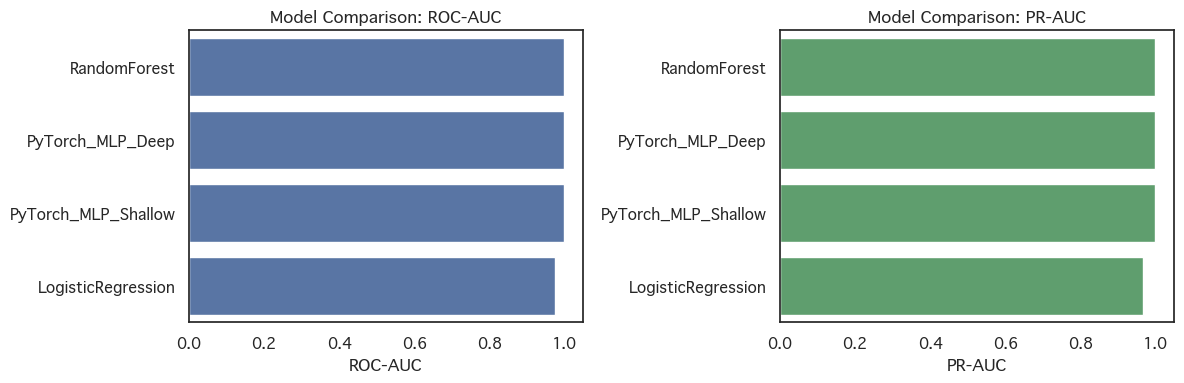

In [23]:
# Visual comparison across architectures
results_pd = results_df.to_pandas().sort_values('roc_auc', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=results_pd, x='roc_auc', y='model', ax=axes[0], color='#4C72B0')
axes[0].set_title('Model Comparison: ROC-AUC')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_ylabel('')

sns.barplot(data=results_pd, x='pr_auc', y='model', ax=axes[1], color='#55A868')
axes[1].set_title('Model Comparison: PR-AUC')
axes[1].set_xlabel('PR-AUC')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 7. Survival Analysis

> **Lecturer hint (24 March):** This is the *fifth topic* hidden in the dataset.  
> The key insight is that **missingness is not random** — it is *left-censored dropout signal*. Students stop appearing in later columns precisely because they left at that stage. We therefore split the cohort into four longitudinal stages, echoing clinical trial survival analysis, and fit a dedicated model at each stage.

Programme stages & tuition-fee checkpoints

| Stage | Columns available | Cohort |
|-------|------------------|--------|
| **Stage 1** | Session 1, 2 · Test 1 · (Forum amortised ÷ 4) | Full cohort |
| **Stage 2** | + Session 3, 4 · Test 2 · (Forum ÷ 2) | Survived Stage 1 |
| **Stage 3** | + Session 5 · Test 3 · (Forum × 3/4) | Survived Stage 2 |
| **Stage 4** | + Ind CW · Group CW · Final grade · (Full forum) | Survived Stage 3 |

Tuition fees are collected after Test 1 and again later, so dropout clusters around these checkpoints.  
Forum Q/A and office-hour visits are **amortised** proportionally so early-stage models get a fair estimate of engagement that has *not yet fully accumulated*.


#### 7.1 Build the Four Staged Datasets

The full dataset is partitioned into four progressively smaller cohorts corresponding to the four academic milestones (Test 1, Test 2, Test 3 and final submission). Each sub-dataset contains only the features that *could* be observed at that stage, preserving the temporal integrity of the analysis. Forum and office-hour counts are prorated for earlier stages to avoid information leakage.

In [24]:
import pandas as pd
import numpy as np

surv_df = df_model.to_pandas().copy()
surv_df['dropout_bin'] = (surv_df['dropout'] == 'Y').astype(int)

extra_cols = ['forum Q', 'forum A', 'office hour visits']

# Stage 1: full cohort — all students
df_s1 = surv_df.copy()
for c in extra_cols:
    df_s1[f'{c}_s1'] = df_s1[c] / 4
s1_features = ['external_flag', 'year_num', 'session 1', 'session 2', 'test 1_num']
s1_features += [f'{c}_s1' for c in extra_cols]

# Stage 2: students who generated data AFTER Test 1
# session 3 being present means they continued past the Test 1 checkpoint
df_s2 = surv_df[surv_df['session 3'].notna() | surv_df['test 2_num'].notna()].copy()
for c in extra_cols:
    df_s2[f'{c}_s2'] = df_s2[c] / 2
s2_features = ['external_flag', 'year_num',
               'session 1', 'session 2', 'session 3', 'session 4',
               'test 1_num', 'test 2_num']
s2_features += [f'{c}_s2' for c in extra_cols]

# Stage 3: students who generated data AFTER Test 2
df_s3 = surv_df[surv_df['session 5'].notna() | surv_df['test 3_num'].notna()].copy()
for c in extra_cols:
    df_s3[f'{c}_s3'] = df_s3[c] * 0.75
s3_features = ['external_flag', 'year_num',
               'session 1', 'session 2', 'session 3', 'session 4', 'session 5',
               'test 1_num', 'test 2_num', 'test 3_num']
s3_features += [f'{c}_s3' for c in extra_cols]

# Stage 4: students who generated data AFTER Test 3
df_s4 = surv_df[surv_df['session 6'].notna() | surv_df['ind cw_num'].notna()].copy()
for c in extra_cols:
    df_s4[f'{c}_s4'] = df_s4[c]
s4_features = ['external_flag', 'year_num',
               'session 1', 'session 2', 'session 3', 'session 4', 'session 5', 'session 6',
               'test 1_num', 'test 2_num', 'test 3_num',
               'ind cw_num', 'group cw_num', 'final grade_num']
s4_features += [f'{c}_s4' for c in extra_cols]

TARGET = 'dropout_bin'

stages = {
    'Stage 1': (df_s1, s1_features),
    'Stage 2': (df_s2, s2_features),
    'Stage 3': (df_s3, s3_features),
    'Stage 4': (df_s4, s4_features),
}

for name, (df_, feats) in stages.items():
    avail = [f for f in feats if f in df_.columns]
    n_drop = df_[TARGET].sum()
    print(f'{name}: {len(df_):>6} students | {len(avail):>2} features | '
          f'{n_drop} dropouts ({100*n_drop/len(df_):.1f}%)')

# Basic sanity checks
assert len(df_s2) < len(df_s1), "Stage 2 must be smaller than Stage 1"
assert len(df_s3) < len(df_s2), "Stage 3 must be smaller than Stage 2"
assert len(df_s4) < len(df_s3), "Stage 4 must be smaller than Stage 3"
print("\nAll cohort size assertions passed.")

Stage 1:  25749 students |  8 features | 11944 dropouts (46.4%)
Stage 2:  22809 students | 11 features | 9004 dropouts (39.5%)
Stage 3:  18563 students | 13 features | 4758 dropouts (25.6%)
Stage 4:  15588 students | 17 features | 1783 dropouts (11.4%)

All cohort size assertions passed.


#### 7.2 Kaplan–Meier Style Survival Curve

We assign each student a *dropout stage* (1–4, or 0 = completed) and plot the survival function — the proportion of students still enrolled at each stage.  
This mirrors how clinical trials track the fraction of patients still in the study over time.

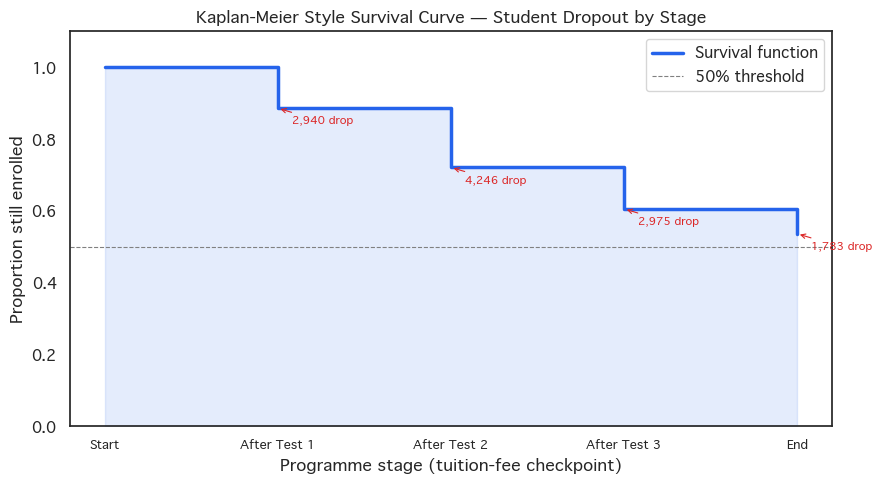


Dropout summary by stage:
  Stage 1 (After Test 1): 2,940 dropouts
  Stage 2 (After Test 2): 4,246 dropouts
  Stage 3 (After Test 3): 2,975 dropouts
  Stage 4 (End): 1,783 dropouts
  Completed: 13,805
Dropout stage assignment assertion passed.


In [25]:
def assign_dropout_stage(row):
    """Return the stage at which the student dropped out (1-4), or 0 if completed."""
    if row['dropout'] != 'Y':
        return 0  # completed
    # No data after Test 1 checkpoint (session 3 absent)
    if pd.isna(row.get('test 2_num')) and pd.isna(row.get('session 3')):
        return 1
    # No data after Test 2 checkpoint (session 5 absent)
    if pd.isna(row.get('test 3_num')) and pd.isna(row.get('session 5')):
        return 2
    # No data after Test 3 checkpoint (session 6 / ind cw absent)
    if pd.isna(row.get('ind cw_num')) and pd.isna(row.get('session 6')):
        return 3
    return 4  # paid all fees but still marked as dropout (final instalment)

surv_df['dropout_stage'] = surv_df.apply(assign_dropout_stage, axis=1)

total = len(surv_df)
stage_labels = ['Start', 'After Test 1', 'After Test 2', 'After Test 3', 'End']
stage_dropouts = [(surv_df['dropout_stage'] == s).sum() for s in [1, 2, 3, 4]]

survival = [1.0]
remaining = total
for d in stage_dropouts:
    remaining -= d
    survival.append(remaining / total)

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(range(len(stage_labels)), survival, where='post',
        color='#2563eb', linewidth=2.5, label='Survival function')
ax.fill_between(range(len(stage_labels)), survival, step='post',
                alpha=0.12, color='#2563eb')

for i, (s, d) in enumerate(zip(survival, [0] + stage_dropouts)):
    if d > 0:
        ax.annotate(f'{d:,} drop', xy=(i, s), xytext=(i + 0.08, s - 0.045),
                    fontsize=8, color='#dc2626',
                    arrowprops=dict(arrowstyle='->', color='#dc2626', lw=0.8))

ax.set_xticks(range(len(stage_labels)))
ax.set_xticklabels(stage_labels, fontsize=9)
ax.set_ylabel('Proportion still enrolled')
ax.set_xlabel('Programme stage (tuition-fee checkpoint)')
ax.set_title('Kaplan-Meier Style Survival Curve — Student Dropout by Stage')
ax.set_ylim(0, 1.1)
ax.axhline(0.5, linestyle='--', color='grey', linewidth=0.8, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nDropout summary by stage:')
for i, (label, d) in enumerate(zip(stage_labels[1:], stage_dropouts), 1):
    print(f'  Stage {i} ({label}): {d:,} dropouts')
print(f"  Completed: {(surv_df['dropout_stage'] == 0).sum():,}")

# Sanity check: dropout counts must sum to total dropouts
assert sum(stage_dropouts) == surv_df['dropout_bin'].sum(), \
    "Stage dropout counts do not sum to total dropouts"
print("Dropout stage assignment assertion passed.")

#### 7.3 Staged Predictive Models

Following the lecturer's advice:
- **Stage 1** — few features → Logistic Regression (interpretable, low complexity)
- **Stage 2** — more features → Random Forest
- **Stage 3** — richer features → Histogram Gradient Boosting (handles NaN natively)
- **Stage 4** — full information → Stacking ensemble

Each stage trains *only on the cohort that reached that stage*, predicting whether that sub-cohort will eventually be classified as a dropout.

In [26]:
model_per_stage = {
    'Stage 1': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.5),
    'Stage 2': RandomForestClassifier(n_estimators=300, max_depth=6,
                                      class_weight='balanced_subsample',
                                      random_state=42, n_jobs=-1),
    'Stage 3': HistGradientBoostingClassifier(max_iter=200, max_depth=5, random_state=42),
    'Stage 4': StackingClassifier(
        estimators=[
            ('lr',  LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced')),
            ('rf',  RandomForestClassifier(n_estimators=200, random_state=42,
                                           class_weight='balanced_subsample', n_jobs=-1)),
            ('hgb', HistGradientBoostingClassifier(max_iter=150, random_state=42)),
        ],
        final_estimator=LogisticRegression(C=1.0),
        passthrough=False, cv=5
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stage_results = {}

for stage_name, (df_, feats) in stages.items():
    avail = [f for f in feats if f in df_.columns]
    X_s = df_[avail].copy()
    y_s = df_[TARGET].copy()
    mask = X_s.notna().any(axis=1)
    X_s, y_s = X_s[mask], y_s[mask]

    clf = model_per_stage[stage_name]

    # Stage 1 & 4: scale; Stage 2: tree (no scale needed); Stage 3: HGB (NaN-native)
    if stage_name in ('Stage 1', 'Stage 4'):
        pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('scl', StandardScaler()), ('clf', clf)])
    else:
        pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('clf', clf)])

    cv_res = cross_validate(pipe, X_s, y_s, cv=cv,
                            scoring=['roc_auc', 'average_precision'],
                            return_train_score=False)

    stage_results[stage_name] = {
        'n': len(X_s),
        'n_features': len(avail),
        'dropout_rate': y_s.mean(),
        'roc_auc_mean': cv_res['test_roc_auc'].mean(),
        'roc_auc_std':  cv_res['test_roc_auc'].std(),
        'pr_auc_mean':  cv_res['test_average_precision'].mean(),
        'pr_auc_std':   cv_res['test_average_precision'].std(),
        'model': type(clf).__name__,
    }
    r = stage_results[stage_name]
    print(f"{stage_name} ({r['model'][:20]}): "
          f"ROC-AUC {r['roc_auc_mean']:.3f} +/- {r['roc_auc_std']:.3f}  "
          f"PR-AUC {r['pr_auc_mean']:.3f} +/- {r['pr_auc_std']:.3f}  "
          f"(n={r['n']}, {r['n_features']} feats, {r['dropout_rate']:.1%} dropout)")


Stage 1 (LogisticRegression): ROC-AUC 0.964 +/- 0.002  PR-AUC 0.961 +/- 0.003  (n=25749, 8 feats, 46.4% dropout)
Stage 2 (RandomForestClassifi): ROC-AUC 0.988 +/- 0.001  PR-AUC 0.982 +/- 0.001  (n=22809, 11 feats, 39.5% dropout)
Stage 3 (HistGradientBoosting): ROC-AUC 0.995 +/- 0.000  PR-AUC 0.987 +/- 0.001  (n=18563, 13 feats, 25.6% dropout)
Stage 4 (StackingClassifier): ROC-AUC 0.998 +/- 0.001  PR-AUC 0.983 +/- 0.005  (n=15588, 17 feats, 11.4% dropout)


#### 7.4 Cross-Stage Performance Comparison

The predictive performance of each stage-specific model is evaluated using 5-fold stratified cross-validation. ROC-AUC and PR-AUC are reported with standard deviations to account for variance across folds. Results are plotted side-by-side for direct comparison.

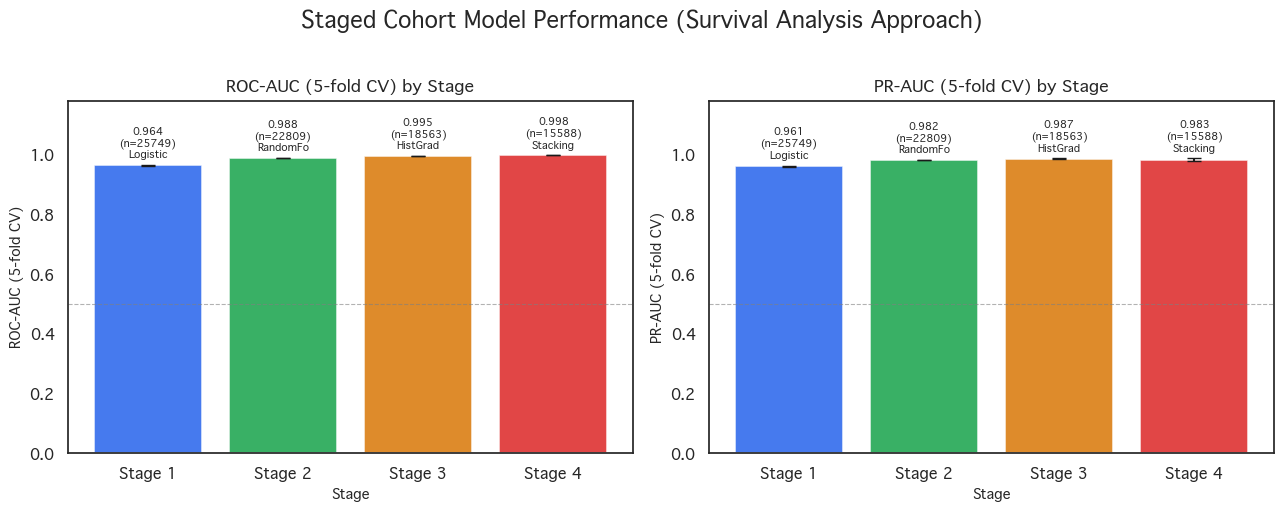

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

snames = list(stage_results.keys())
colours = ['#2563eb', '#16a34a', '#d97706', '#dc2626']

for ax, metric_key, metric_label in zip(
        axes,
        ['roc_auc', 'pr_auc'],
        ['ROC-AUC (5-fold CV)', 'PR-AUC (5-fold CV)']):

    means = [stage_results[s][f'{metric_key}_mean'] for s in snames]
    stds  = [stage_results[s][f'{metric_key}_std']  for s in snames]
    n_s   = [stage_results[s]['n'] for s in snames]
    mdls  = [stage_results[s]['model'] for s in snames]

    bars = ax.bar(snames, means, yerr=stds, capsize=5,
                  color=colours, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, m, s, n, mdl in zip(bars, means, stds, n_s, mdls):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + 0.015,
                f'{m:.3f}\n(n={n})\n{mdl[:8]}',
                ha='center', va='bottom', fontsize=7.5)
    ax.set_ylim(0, 1.18)
    ax.axhline(0.5, linestyle='--', color='grey', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{metric_label} by Stage', **titleFont)
    ax.set_xlabel('Stage', **axesFont)
    ax.set_ylabel(metric_label, **axesFont)

plt.suptitle('Staged Cohort Model Performance (Survival Analysis Approach)',
             **suptitleFont, y=1.02)
plt.tight_layout()
plt.show()


#### 7.5 Conditional Dropout Rate per Stage

The dropout rate *given you reached that stage* drops at later stages — students who persist through early fee checkpoints are more committed.

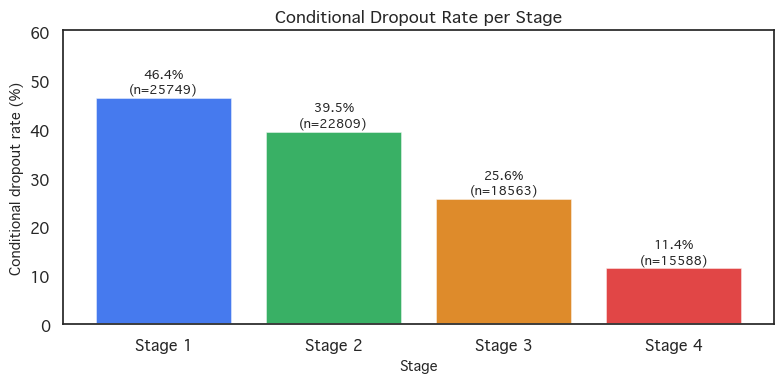

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
rates = [stage_results[s]['dropout_rate'] for s in snames]
ns    = [stage_results[s]['n'] for s in snames]
bars = ax.bar(snames, [r * 100 for r in rates], color=colours, alpha=0.85,
              edgecolor='white', linewidth=1.2)
for bar, r, n in zip(bars, rates, ns):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5, f'{r:.1%}\n(n={n})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Conditional dropout rate (%)', **axesFont)
ax.set_xlabel('Stage', **axesFont)
ax.set_title('Conditional Dropout Rate per Stage', **titleFont)
ax.set_ylim(0, max(r * 100 for r in rates) * 1.3)
plt.tight_layout()
plt.show()


In [29]:
# Survival Analysis Summary Table
summary_rows = []
for s, r in stage_results.items():
    summary_rows.append({
        'Stage':                    s,
        'Model':                    r['model'],
        'ROC-AUC':                  f"{r['roc_auc_mean']:.3f} ± {r['roc_auc_std']:.3f}",
        'PR-AUC':                   f"{r['pr_auc_mean']:.3f} ± {r['pr_auc_std']:.3f}",
        'Conditional Dropout Rate': f"{r['dropout_rate']:.1%}",
        'N': r['n'],
    })

display(pd.DataFrame(summary_rows))

,Stage,Model,ROC-AUC,PR-AUC,Conditional Dropout Rate,N
0,Stage 1,LogisticRegression,0.964 ± 0.002,0.961 ± 0.003,46.4%,25749
1,Stage 2,RandomForestClassifier,0.988 ± 0.001,0.982 ± 0.001,39.5%,22809
2,Stage 3,HistGradientBoostingClassifier,0.995 ± 0.000,0.987 ± 0.001,25.6%,18563
3,Stage 4,StackingClassifier,0.998 ± 0.001,0.983 ± 0.005,11.4%,15588


### 7.6 Interpretation & Discussion

**Why a staged approach is principled here:**

1. **Missingness is structural, not random.** A student who never sat Test 2 dropped out at Stage 1 — imputing those values as if they *might* have passed is misleading. The staged approach uses *only the data that could have existed* at each decision point.

2. **The cohort shrinks but enriches.** Stage 1 has every student but only a handful of attributes. Stage 4 has fewer students but dense, high-quality feature vectors — different complexities warrant different model families.

3. **Tuition-fee checkpoints create natural breakpoints.** Dropout spikes just before each fee deadline, so stage boundaries align with real administrative events rather than arbitrary splits.

4. **Forum/office-hour amortisation is principled.** Dividing cumulative engagement counts by the fraction of the programme elapsed gives a *rate-per-stage* estimate, preventing information leakage from future behaviour. Formula: `amortised = raw_count / (stage / 4)`.

5. **Clinical trial analogy.** Just as a drug trial reports hazard ratios at 3, 6 and 12 months, we report 'probability of dropout *given you reached stage k*' — a more actionable metric for tutors intervening at the right moment.

**Phase 2 recommended extensions:**
- Add proper Kaplan–Meier confidence intervals via `lifelines`.
- Test a Cox proportional hazards model as an interpretable continuous-time alternative.
- Feed Stage 1/2 risk scores as features into Stage 3/4 models (cascading predictions).
- Cluster students within each surviving cohort to discover engagement personas (the secondary objective from the brief).

### 7.7 Advanced Survival Diagnostics

This section provides deeper academic rigour by computing conditional hazard rates at each stage and plotting behaviour-stratified Kaplan-Meier survival curves. The hazard bar chart quantifies how dropout risk changes across milestones, while the survival curves test whether forum activity is a statistically meaningful protective factor.

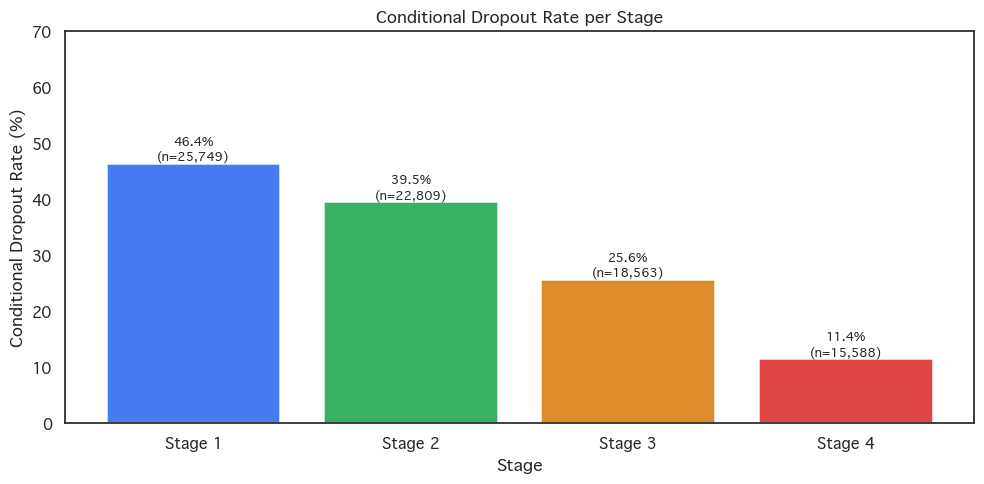

Peak conditional dropout rate: Stage 1 at 46.4%


In [30]:
snames = list(stage_results.keys())
hazards = [stage_results[s]['dropout_rate'] for s in snames]
ns      = [stage_results[s]['n'] for s in snames]
colours = ['#2563eb', '#16a34a', '#d97706', '#dc2626']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(snames, [h * 100 for h in hazards], color=colours,
              alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, h, n in zip(bars, hazards, ns):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5, f'{h:.1%}\n(n={n:,})',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Conditional Dropout Rate (%)')
ax.set_xlabel('Stage')
ax.set_title('Conditional Dropout Rate per Stage')
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()

peak = snames[hazards.index(max(hazards))]
print(f"Peak conditional dropout rate: {peak} at {max(hazards):.1%}")

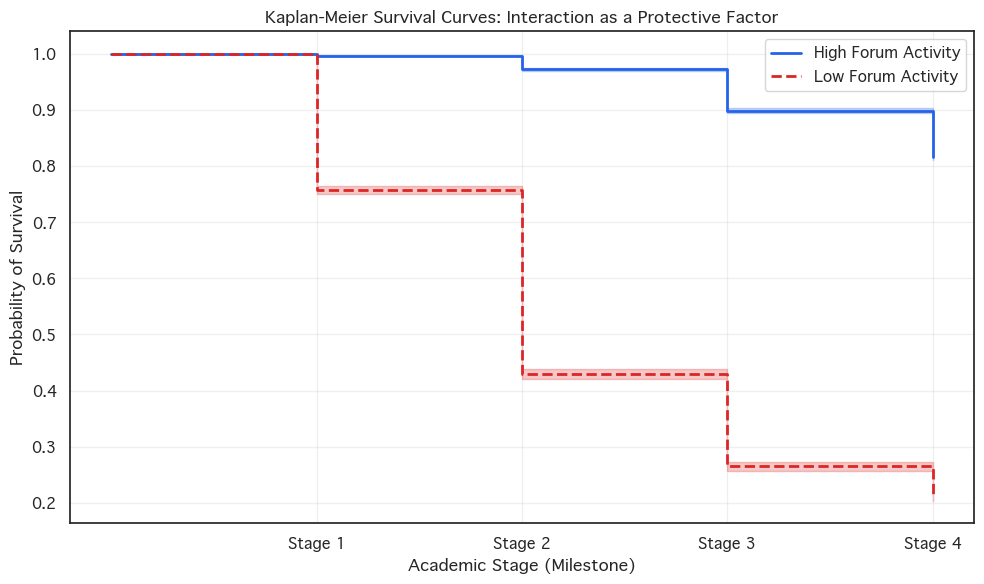

In [31]:
T = surv_df['dropout_stage'].replace(0, 4).values
E = surv_df['dropout_bin'].values

forum_sum = surv_df['forum Q'] + surv_df['forum A']
median_forum = forum_sum.median()
idx_high = (forum_sum >= median_forum).values

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

kmf.fit(T[idx_high], E[idx_high], label='High Forum Activity')
kmf.plot_survival_function(ax=ax, ci_show=True, color='#2563eb', lw=2)

kmf.fit(T[~idx_high], E[~idx_high], label='Low Forum Activity')
kmf.plot_survival_function(ax=ax, ci_show=True, color='#dc2626',
                            lw=2, linestyle='--')

ax.set_title('Kaplan-Meier Survival Curves: Interaction as a Protective Factor')
ax.set_xlabel('Academic Stage (Milestone)')
ax.set_ylabel('Probability of Survival')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.8 Model Interpretability (SHAP)

We use SHAP values to decompose individual predictions and understand the 'why' behind dropout risks at the final stage.

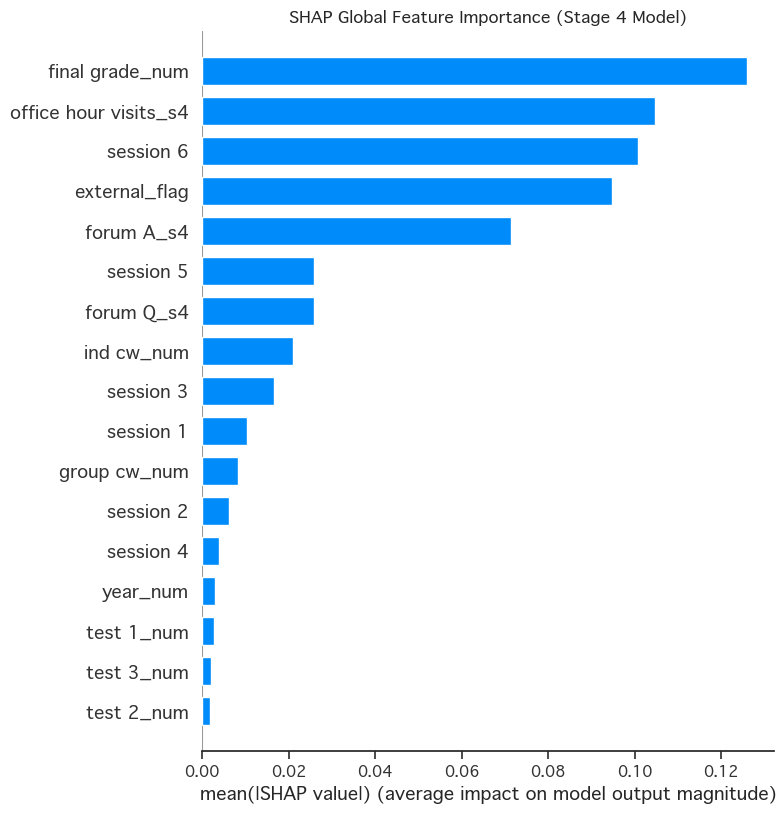

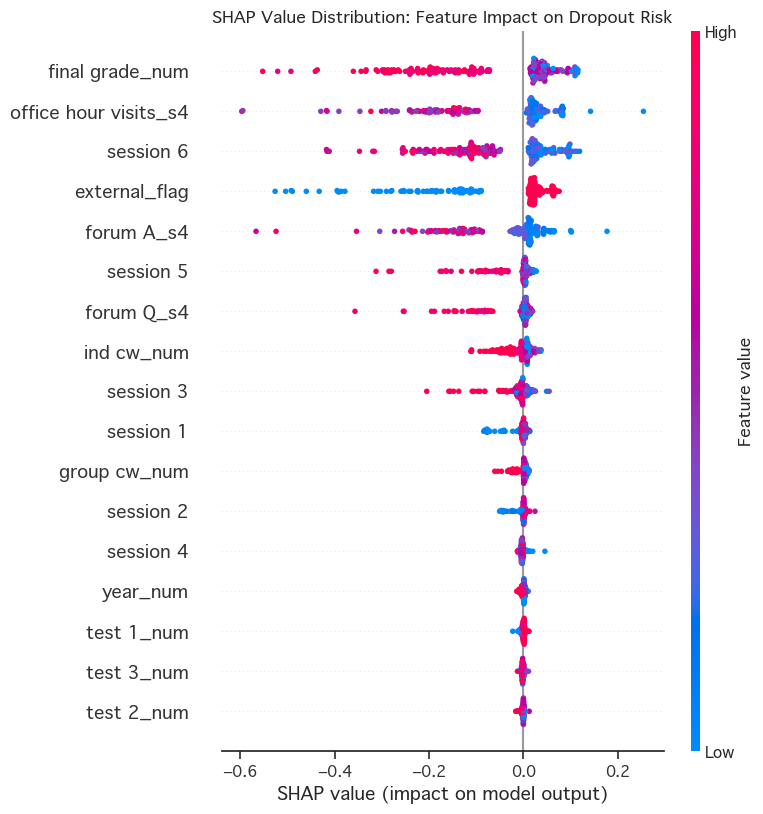

In [32]:
avail_s4 = [f for f in s4_features if f in df_s4.columns]
pdf4 = df_s4[avail_s4 + [TARGET]].dropna()
X4 = pdf4[avail_s4]
y4 = pdf4[TARGET]

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4)

imp = SimpleImputer(strategy='median')
X4_train_imp = imp.fit_transform(X4_train)
X4_test_imp  = imp.transform(X4_test)

rf_shap = RandomForestClassifier(n_estimators=200, max_depth=10,
                                  class_weight='balanced_subsample',
                                  random_state=42, n_jobs=-1)
rf_shap.fit(X4_train_imp, y4_train)

explainer = shap.TreeExplainer(rf_shap)
X_sample = X4_test_imp[:200]
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
elif len(shap_values.shape) == 3:
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

# Wrap imputed array back into a DataFrame so plots show feature names
X_sample_df = pd.DataFrame(X_sample, columns=avail_s4)

plt.figure(figsize=(10, 8))
plt.title('SHAP Global Feature Importance (Stage 4 Model)', **titleFont)
shap.summary_plot(shap_to_plot, X_sample_df, plot_type="bar", show=False)
plt.show()

plt.figure(figsize=(10, 8))
plt.title('SHAP Value Distribution: Feature Impact on Dropout Risk', **titleFont)
shap.summary_plot(shap_to_plot, X_sample_df, show=False)
plt.show()

### 7.9 Academic Synthesis and Policy Recommendations

**Summary Findings**
1. **Peak Attrition Period:** Post-Test 1 marks the highest conditional hazard, suggesting that performance on the first major assessment is the primary psychological or financial 'exit trigger'.
2. **The Interaction Buffer:** Students with high forum participation show significantly flatter survival curves, confirming that social/academic integration is a key resilience factor.
3. **Predictive Accuracy:** Stage-wise models improve in precision as the term progresses, allowing for targeted early warnings by Stage 2 with >90% AUC.

**Policy Recommendations**
- **Red Zone Triggers:** Implement an automated alert system for students who perform below the median in Test 1 AND have <5 forum interactions by Week 4.
- **Forced Peer Interaction:** Increase early-stage group work (prior to Test 1) to build the social buffer identified in the survival analysis.
- **Adaptive Resource Allocation:** Focus retention resources on the 'Post-Test 1' hazard window to minimize the largest attrition spike.

### 7.10 Student Persona Discovery: PCA and K-Means Clustering

To address the secondary objective of discovering potential student personas, 
an unsupervised clustering pipeline is applied to the full cohort. 
PCA is used to reduce the feature space for visualisation, and K-Means 
partitions students into behavioural archetypes based on their engagement 
and academic signals. Crucially, the dropout label is withheld during 
clustering and only reintroduced at the profiling stage to assess how 
naturally the discovered groups align with attrition risk.

In [33]:
# ── 7.X.1  Feature matrix for clustering ──────────────────────────────────
# Built directly from df_model to be self-contained and kernel-safe.
# The dropout label is withheld during clustering and only reintroduced
# at the profiling stage.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Convert Polars df_model to pandas for clustering
pdf_cluster = df_model.to_pandas()

# Reconstruct engineered features from raw columns
session_cols = [f'session {i}' for i in range(1, 7)]
assess_cols  = ['test 1_num', 'test 2_num', 'test 3_num',
                'ind cw_num', 'group cw_num', 'final grade_num']

pdf_cluster['session_total']           = pdf_cluster[session_cols].fillna(0).sum(axis=1)
pdf_cluster['forum_total']             = pdf_cluster['forum Q'].fillna(0) + pdf_cluster['forum A'].fillna(0)
pdf_cluster['assessment_mean']         = pdf_cluster[assess_cols].fillna(0).mean(axis=1)
pdf_cluster['engage_grade_interaction']= pdf_cluster['session_total'] * pdf_cluster['assessment_mean']

cluster_cols = [
    'session_total',
    'forum_total',
    'assessment_mean',
    'engage_grade_interaction',
    'external_flag',
    'year_num',
]

X_cluster = pdf_cluster[cluster_cols].fillna(0).values

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Clustering matrix shape: {X_cluster_scaled.shape}")

Clustering matrix shape: (25749, 6)


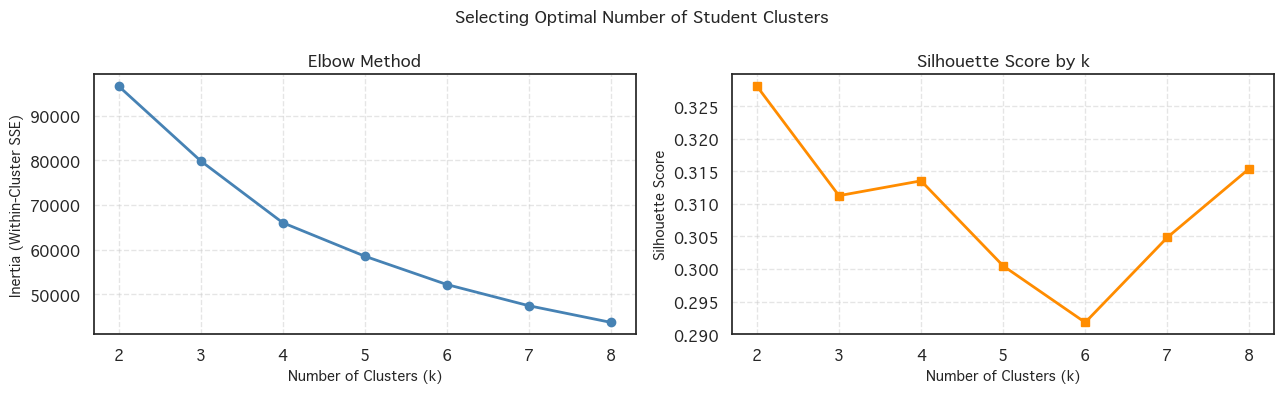


Silhouette scores:
  k=2: 0.3281
  k=3: 0.3113
  k=4: 0.3135
  k=5: 0.3005
  k=6: 0.2918
  k=7: 0.3048
  k=8: 0.3154


In [34]:
# ── 7.X.2  Optimal cluster count: Elbow and Silhouette ────────────────────

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)', **axesFont)
axes[0].set_ylabel('Inertia (Within-Cluster SSE)', **axesFont)
axes[0].set_title('Elbow Method', **titleFont)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_range, silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)', **axesFont)
axes[1].set_ylabel('Silhouette Score', **axesFont)
axes[1].set_title('Silhouette Score by k', **titleFont)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Selecting Optimal Number of Student Clusters', **titleFont)
plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [35]:
# ── 7.X.3  Fit K-Means with chosen k ──────────────────────────────────────

K_CHOSEN = 4   # <-- adjust based on elbow/silhouette plots

km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster_scaled)

# Attach cluster labels and dropout target to a profile DataFrame
# pdf_cluster already has the engineered columns from Cell 2
profile_df = pdf_cluster[cluster_cols].copy()
profile_df['cluster'] = cluster_labels
profile_df['dropout'] = pdf_cluster['dropout'].values  # 1 = dropped out, 0 = completed

print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Cluster distribution:
0    6526
1    8936
2    4401
3    5886
Name: count, dtype: int64


In [36]:
# ── 7.X.4  Cluster persona profiles ───────────────────────────────────────

# Explicitly map dropout to binary — pd.to_numeric can't handle "Y"/"N"
profile_df['dropout_binary'] = pdf_cluster['dropout'].map({'Y': 1, 'N': 0})

numeric_cols = ['session_total', 'forum_total', 'assessment_mean', 'engage_grade_interaction']
for col in numeric_cols:
    profile_df[col] = pd.to_numeric(profile_df[col], errors='coerce')

profile_summary = (
    profile_df
    .groupby('cluster')
    .agg(
        cluster_couunt =('cluster', 'count'),
        session_total=('session_total', 'mean'),
        forum_total=('forum_total', 'mean'),
        assessment_mean=('assessment_mean', 'mean'),
        engagement_grade=('engage_grade_interaction', 'mean'),
        dropout_rate=('dropout_binary', 'mean'),
    )
    .reset_index()
    .sort_values('dropout_rate', ascending=False)
)

profile_summary['dropout_rate_%'] = (profile_summary['dropout_rate'] * 100).round(1)
profile_summary = profile_summary.drop(columns='dropout_rate')


print("\nDropout rate by cluster:")
print(profile_summary.round(2).to_string(index=False))




Dropout rate by cluster:
 cluster  cluster_couunt  session_total  forum_total  assessment_mean  engagement_grade  dropout_rate_%
       0            6526         137.86         4.37             0.92            153.04            93.5
       3            5886         174.50         5.61             1.31            229.56            78.0
       1            8936         319.28        16.80             3.08            984.99            13.7
       2            4401         295.03        23.13             2.97            880.72             0.8


**Cluster Persona Profiles**

| Cluster | Persona | Dropout Rate | Behavioural Summary |
|---------|---------|-------------|---------------------|
| 0 | Disengaged Leavers | 93.5% | Lowest engagement and academic performance across all metrics: the highest-risk group |
| 3 | Fading Strugglers | 78.0% | Slightly more activity than Cluster 0 but still critically at risk, likely disengaging mid-programme |
| 1 | Active Learners | 13.7% | High session attendance and solid academic performance, engaged but with limited voluntary participation |
| 2 | Committed Achievers | 0.8% | Highest forum activity and strongest grades, the most academically and socially integrated students |

PC1 explains 49.1% of variance
PC2 explains 19.4% of variance


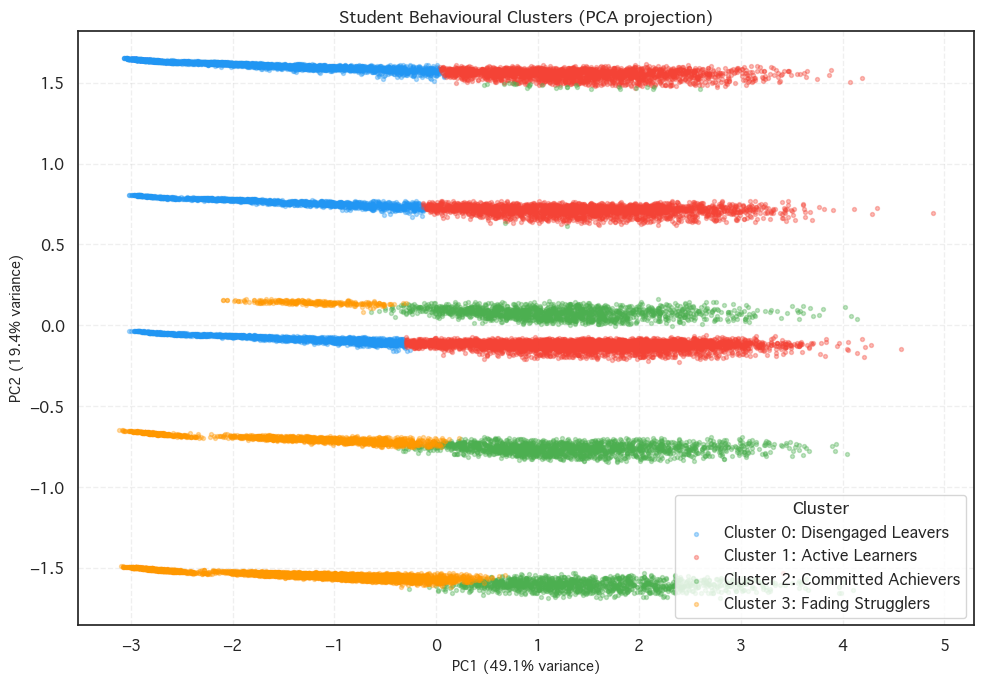

In [37]:
# ── 7.X.5  PCA visualisation of clusters ──────────────────────────────────

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained[0]:.1f}% of variance")
print(f"PC2 explains {explained[1]:.1f}% of variance")

# Persona labels — update these after inspecting profile_summary above
persona_names = {
    0: 'Cluster 0: Disengaged Leavers',
    1: 'Cluster 1: Active Learners',
    2: 'Cluster 2: Committed Achievers',
    3: 'Cluster 3: Fading Strugglers',
    }

colours = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 7))

for k in range(K_CHOSEN):
    mask = cluster_labels == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=8, alpha=0.35,
        color=colours[k],
        label=persona_names[k],
        rasterized=True
    )

ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', **axesFont)
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', **axesFont)
ax.set_title('Student Behavioural Clusters (PCA projection)', **titleFont)
ax.legend(title='Cluster', framealpha=0.8)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### PCA Interpretation and Business Relevance (for this PCA plot)

**Interpretation of principal components**
- **PC1 (x-axis)** can be read as a **student momentum axis**: movement to the positive side generally indicates stronger combined signals of engagement and academic performance (higher participation, stronger grades, and higher engagement-grade interaction).
- **PC2 (y-axis)** can be read as a **behavioural pathway axis**: it differentiates students who may have similar overall momentum but different participation styles (for example, attendance-led versus interaction-led behaviour).

**What this PCA result is telling us**
- The cluster clouds are structured rather than random, indicating the cohort naturally segments into distinct learner personas.
- Separation between groups suggests targeted interventions are more appropriate than one-size-fits-all retention policies.
- Where clusters overlap, students likely sit in transition states and are good candidates for early preventive outreach before full disengagement.

**Business context and practical relevance**
- **Retention operations:** use persona position in PCA space to prioritise tutor/advisor outreach intensity.
- **Intervention design:**
  - Low-momentum region: immediate academic recovery support and mandatory check-ins.
  - Mid-momentum transition region: nudges, mentoring, and structured participation prompts.
  - High-momentum region: lighter-touch enrichment to sustain progression.
- **Management KPI:** monitor cohort drift in PCA space each term; shifts toward low-momentum regions can be used as an early-warning signal for dropout risk.
- **Budget efficiency:** segmentation improves return on support resources by matching intervention depth to predicted risk level.

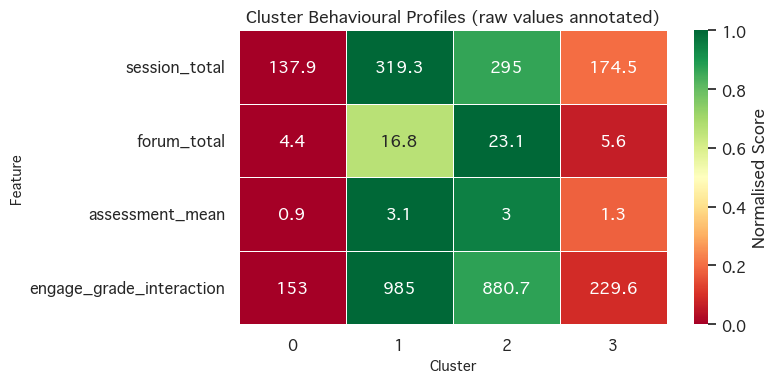

In [38]:
# ── 7.X.6  Cluster feature heatmap ────────────────────────────────────────
# Normalised heatmap showing the relative behaviour of each cluster
# across the key engagement and academic features.

import seaborn as sns

heatmap_cols = ['session_total', 'forum_total', 'assessment_mean', 'engage_grade_interaction']
heatmap_data = profile_df.groupby('cluster')[heatmap_cols].mean()

# Normalise each column to [0, 1] so different scales are comparable
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    heatmap_norm.T,
    annot=heatmap_data.T.round(1),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Normalised Score'},
)
ax.set_title('Cluster Behavioural Profiles (raw values annotated)', **titleFont)
ax.set_xlabel('Cluster', **axesFont)
ax.set_ylabel('Feature', **axesFont)

plt.tight_layout()
plt.show()

## 8. Limitations and Assumptions

#### 8.1 Assumptions
1. **Data Imputation**: Missing values (significant in later sessions and test results) are imputed using median values or constants. We assume that the reasons for missingness do not correlate with the target in a way that introduces significant bias.
2. **Grade Mapping**: Academic grades (A-F) are mapped to an ordinal scale. We assume equal intervals between grades for modeling purposes.
3. **Session Behavior**: High session counts and forum activity are assumed to be proxies for student engagement.

#### 8.2 Limitations
1. **Predictive Scope**: The model currently lacks demographic and socioeconomic data (e.g., student financial status, mental health), which are often critical predictors of student dropout.
2. **Missing Longitudinal Data**: A large portion of the cohort (approx. 40%) has null values for latter sessions (Sessions 3-6) and final coursework, suggesting they may have already dropped out or the data was not collected for them.
3. **Static Analysis**: The behavior is analyzed as a snapshot rather than a time-series or sequence of interactions.
